<a href="https://colab.research.google.com/github/sonaliliyanahetti/Final-Year-Research-Malaria-Detection-Models/blob/main/FF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Paths and setup
import os, random, math, shutil, pathlib

DATASET_PATH = "/content/drive/MyDrive/Research/archive/cell_images/cell_images"  # <-- adjust if needed
WORK_DIR = "/content/malaria_subset_4k"
os.makedirs(WORK_DIR, exist_ok=True)

classes = ["Uninfected", "Parasitized"]

In [ ]:
# 3. Create 2000-image subset (1000 per class)
files_by_class = {}
SAMPLES_PER_CLASS = 1000  # <-- requested
for cls in classes:
    cls_dir = pathlib.Path(DATASET_PATH) / cls
    files = [str(p) for p in cls_dir.glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
    random.shuffle(files)
    if len(files) < SAMPLES_PER_CLASS:
        raise ValueError(f"Not enough images in {cls}: found {len(files)}, need {SAMPLES_PER_CLASS}")
    files_by_class[cls] = files[:SAMPLES_PER_CLASS]


In [ ]:
# Split 70/15/15
splits = {"train": 0.7, "val": 0.15, "test": 0.15}
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(WORK_DIR, split, cls), exist_ok=True)

for cls in classes:
    files = files_by_class[cls]
    n = len(files)
    n_train = math.floor(n * splits["train"])     # 1400 per class
    n_val   = math.floor(n * splits["val"])       # 300 per class
    train_files = files[:n_train]
    val_files   = files[n_train:n_train+n_val]
    test_files  = files[n_train+n_val:]

    for f in train_files:
        shutil.copy(f, os.path.join(WORK_DIR, "train", cls, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(WORK_DIR, "val", cls, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(WORK_DIR, "test", cls, os.path.basename(f)))

print("Subset created at:", WORK_DIR)

Subset created at: /content/malaria_subset_4k


In [ ]:


import numpy as np
import os, random, math, shutil, pathlib, cv2, warnings
import tensorflow as tf
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from sklearn.metrics import (silhouette_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve)

In [ ]:
import pandas as pd

def parasite_inflatter(image_uint8):
    """
    Inflate parasite visibility using CLAHE + morphological dilation.
    Input:  uint8 RGB image [H, W, 3]
    Output: uint8 RGB image [H, W, 3]
    """
    # Step 1: Convert to LAB
    lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Step 2: CLAHE on L channel
    # clipLimit=3.0 means don't amplify noise beyond 3x; tileGridSize divides image into 8x8 local regions
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)

    # Step 3: Merge back
    lab_enhanced = cv2.merge([l_enhanced, a, b])
    enhanced_rgb = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

    # Step 4: Inflate dark (parasite) blobs via morphological dilation
    # Convert to grayscale to find dark blobs
    gray = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2GRAY)
    # Dark regions = parasite candidates
    _, dark_mask = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)
    # Dilate the mask (inflate blobs by 2 pixels radius)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    inflated_mask = cv2.dilate(dark_mask, kernel, iterations=1)

    # Blend: use inflated mask to slightly darken those regions in the enhanced image
    # This makes parasites stand out more visually
    enhanced_rgb_float = enhanced_rgb.astype(np.float32)
    mask_3ch = np.stack([inflated_mask / 255.0] * 3, axis=-1)
    inflated = (enhanced_rgb_float * (1 - 0.3 * mask_3ch)).clip(0, 255).astype(np.uint8)

    return inflated


In [ ]:
def stain_normalize(image_uint8, target_mean=None, target_std=None):
    """
    Normalize Giemsa stain appearance.
    Uses log-OD space to equalize stain intensity across images.
    """
    if target_mean is None:
        target_mean = np.array([148.60, 169.26, 190.44])  # typical Giemsa reference
    if target_std is None:
        target_std  = np.array([41.56, 38.28, 38.16])

    img = image_uint8.astype(np.float32) + 1e-6  # avoid log(0)
    # Per-channel mean/std normalization
    for c in range(3):
        img[:, :, c] = (img[:, :, c] - img[:, :, c].mean()) / (img[:, :, c].std() + 1e-6)
        img[:, :, c] = img[:, :, c] * target_std[c] + target_mean[c]

    return np.clip(img, 0, 255).astype(np.uint8)


In [ ]:
def background_suppressor(image_uint8):
    """
    Remove slide background, retain only cell regions.
    """
    gray = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
    # Otsu threshold
    _, cell_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Keep cell region
    result = image_uint8.copy()
    result[cell_mask == 0] = 0
    return result

In [ ]:
def full_preprocess(image_tensor):
    """
    Apply: Stain Normalization → Parasite Inflatter → Background Suppressor
    Then normalize to [-1, 1] for the model.
    """
    # Convert float [0,1] tensor to uint8
    img = tf.cast(image_tensor * 255.0, tf.uint8).numpy()

    img = stain_normalize(img)        # Step 1: normalize stain color
    img = parasite_inflatter(img)     # Step 2: inflate parasite visibility
    img = background_suppressor(img)  # Step 3: suppress background

    # Final normalization to [-1, 1] (MobileNet-style, compatible with ViT)
    out = img.astype(np.float32) / 127.5 - 1.0
    return out

In [ ]:
def tf_preprocess(x_batch, y_batch):
    """Wrapper for use in tf.data.Dataset.map(), applies full_preprocess to each image in the batch."""
    # Use tf.map_fn to apply the Python function (via tf.py_function) to each image in the batch
    x_out_batch = tf.map_fn(
        fn=lambda single_img: tf.py_function(
            func=full_preprocess,  # full_preprocess expects a single image tensor
            inp=[single_img],
            Tout=tf.float32
        ),
        elems=x_batch, # x_batch is (batch_size, H, W, C)
        fn_output_signature=tf.TensorSpec(shape=[*IMG_SIZE, 3], dtype=tf.float32)
    )
    return x_out_batch, y_batch


In [ ]:
# 4. tf.data pipeline
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # reduce to 16 if you hit GPU memory limits
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(split):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(WORK_DIR, split),
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=(split == "train"),
    )
    return ds

train_ds = make_ds("train")
val_ds   = make_ds("val")
test_ds  = make_ds("test")

# Augmentation + preprocessing
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

def prepare(ds, training=False):
    ds = ds.map(tf_preprocess, num_parallel_calls=AUTOTUNE)  # use your full_preprocess
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(4096)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds   = prepare(val_ds, training=False)
test_ds  = prepare(test_ds, training=False)


Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [ ]:
# 5. CNN + ViT hybrid
from tensorflow import keras
from tensorflow.keras import layers

def transformer_block(x, num_heads, mlp_dim, dropout=0.1):
    # LayerNorm + MHA
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1], dropout=dropout)(x_norm, x_norm)
    x = layers.Add()([x, attn])

    # LayerNorm + MLP
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp = layers.Dense(mlp_dim, activation="gelu")(x_norm)
    mlp = layers.Dropout(dropout)(mlp)
    mlp = layers.Dense(x.shape[-1])(mlp)
    x = layers.Add()([x, mlp])
    return x

def build_cnn_vit(input_shape=(224, 224, 3),
                  cnn_channels=(32, 64, 128),
                  patch_size=16,
                  embed_dim=256,
                  num_transformer_blocks=4,
                  num_heads=8,
                  mlp_dim=512,
                  dropout=0.1):
    inputs = keras.Input(shape=input_shape)

    # CNN stem: downsample and enrich local features
    x = inputs
    for c in cnn_channels:
        x = layers.Conv2D(c, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(c, 3, padding="same", activation="relu")(x)
        x = layers.MaxPool2D()(x)  # reduces H,W

    # Ensure spatial dims divisible by patch_size
    # Resize feature map to a size divisible by patch_size (tokens grid)
    h, w = x.shape[1], x.shape[2]
    target_h = (h // patch_size) * patch_size
    target_w = (w // patch_size) * patch_size
    x = layers.Resizing(target_h, target_w, interpolation="bilinear")(x)

    # Linear projection of patches (Conv with stride=patch_size acts as patchify+proj)
    x = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(x)  # [B, H', W', D]
    h_tokens, w_tokens = x.shape[1], x.shape[2]
    num_tokens = h_tokens * w_tokens

    # Flatten to tokens
    x = layers.Reshape((num_tokens, embed_dim))(x)

    # Optional positional embedding
    pos_embed = layers.Embedding(input_dim=num_tokens, output_dim=embed_dim)
    positions = tf.range(start=0, limit=num_tokens, delta=1)
    x = x + pos_embed(positions)

    # Transformer encoder
    for _ in range(num_transformer_blocks):
        x = transformer_block(x, num_heads=num_heads, mlp_dim=mlp_dim, dropout=dropout)

    # Token pooling (mean pooling tends to be stable)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(mlp_dim, activation="gelu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="cnn_vit_hybrid")
    return model

model = build_cnn_vit(
    input_shape=(224, 224, 3),
    cnn_channels=(32, 64, 128),
    patch_size=16,        # tokens grid ~ 7x7 or 8x8 depending on stem
    embed_dim=256,
    num_transformer_blocks=4,
    num_heads=8,
    mlp_dim=512,
    dropout=0.1
)

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="acc"), keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "cnn_vit_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 1, 1, 256) │  8,388,864 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 256)    │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 256)    │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 256)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 256)    │        512 │ add_1[0][0]     

 Total params: 18,278,433 (69.73 MB)

 Trainable params: 18,278,433 (69.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6. Train
callbacks = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_acc"),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# 7. Evaluation
test_metrics = model.evaluate(test_ds)
print("Test metrics:", dict(zip(model.metrics_names, test_metrics)))

import numpy as np
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred = np.concatenate([model.predict(x).ravel() for x, _ in test_ds], axis=0)
y_hat = (y_pred >= 0.5).astype(int)
acc = (y_hat == y_true).mean()
print(f"Thresholded test accuracy: {acc:.4f}")

from sklearn.metrics import roc_curve

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred = np.concatenate([model.predict(x).ravel() for x, _ in test_ds], axis=0)

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
optimal_idx = np.argmax(tpr - fpr)
THRESHOLD = thresholds[optimal_idx]
print(f"Optimal threshold: {THRESHOLD:.3f}")





Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


44/44 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - acc: 0.5721 - auc: 0.6009 - loss: 0.7090 - val_acc: 0.4967 - val_auc: 0.7554 - val_loss: 0.7988 - learning_rate: 3.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - acc: 0.6743 - auc: 0.7144 - loss: 0.6288 - val_acc: 0.7533 - val_auc: 0.8427 - val_loss: 0.4908 - learning_rate: 3.0000e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - acc: 0.8257 - auc: 0.8793 - loss: 0.4288 - val_acc: 0.7533 - val_auc: 0.8764 - val_loss: 0.5321 - learning_rate: 3.0000e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 204ms/step - acc: 0.8886 - auc: 0.9253 - loss: 0.3182 - val_acc: 0.8267 - val_auc: 0.8898 - val_loss: 0.4346 - learning_rate: 3.0000e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 242ms/step - acc: 0.8800 - auc: 0.9376 - loss: 0.3015 - val_acc: 0.8533 - val_auc: 0.9100 - val_loss: 0.5029 - learning_rate: 3.0000e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 33s 206ms/step - acc: 0.8907 - auc: 0.9345 - loss: 0.3034 - val_acc: 0.8500 - va

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Thresholded test accuracy: 0.5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Optimal threshold: 0.200



=== Classification Report ===
              precision    recall  f1-score   support

 Parasitized       0.80      0.98      0.88       150
  Uninfected       0.97      0.76      0.85       150

    accuracy                           0.87       300
   macro avg       0.89      0.87      0.87       300
weighted avg       0.89      0.87      0.87       300



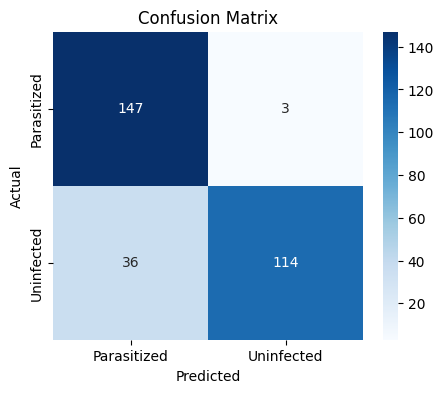

<Figure size 640x480 with 0 Axes>

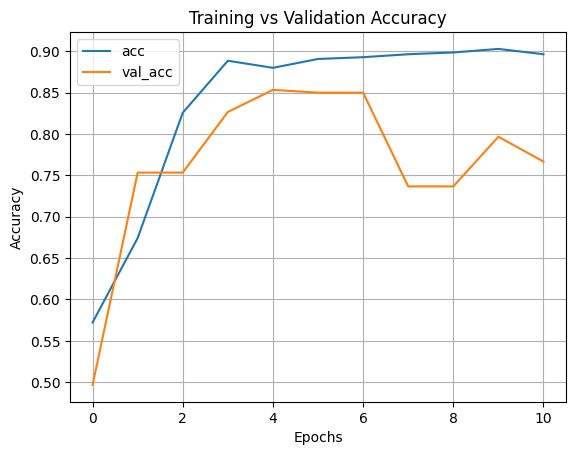

<Figure size 640x480 with 0 Axes>

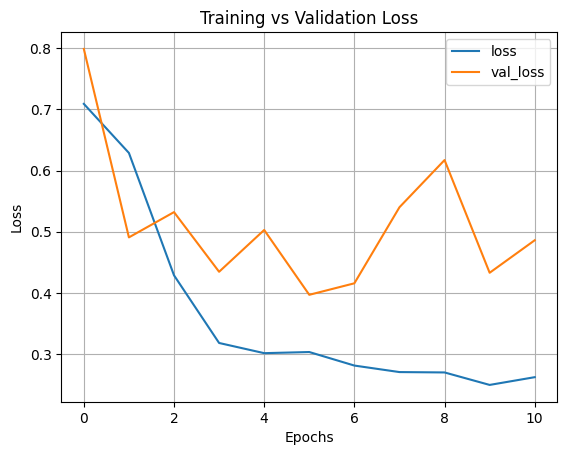

In [ ]:
# 9. Visualization (confusion matrix & curves)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print("\n=== Classification Report ===")
from sklearn.metrics import classification_report
print(classification_report(y_true, y_hat, target_names=classes))

cm = confusion_matrix(y_true, y_hat)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

history_df = pd.DataFrame(history.history)
plt.figure()
history_df[['acc', 'val_acc']].plot()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
history_df[['loss', 'val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


🔬 Extracting features and classifying species...
✅ Classified 117 infected cells

📊 Species Distribution:
Predicted_Species
P.falciparum    53
P.knowlesi      38
P.vivax         26
Name: count, dtype: int64

🎯 Average Confidence per Species:
Predicted_Species
P.falciparum    0.261
P.knowlesi      0.323
P.vivax         0.299
Name: Confidence, dtype: float64


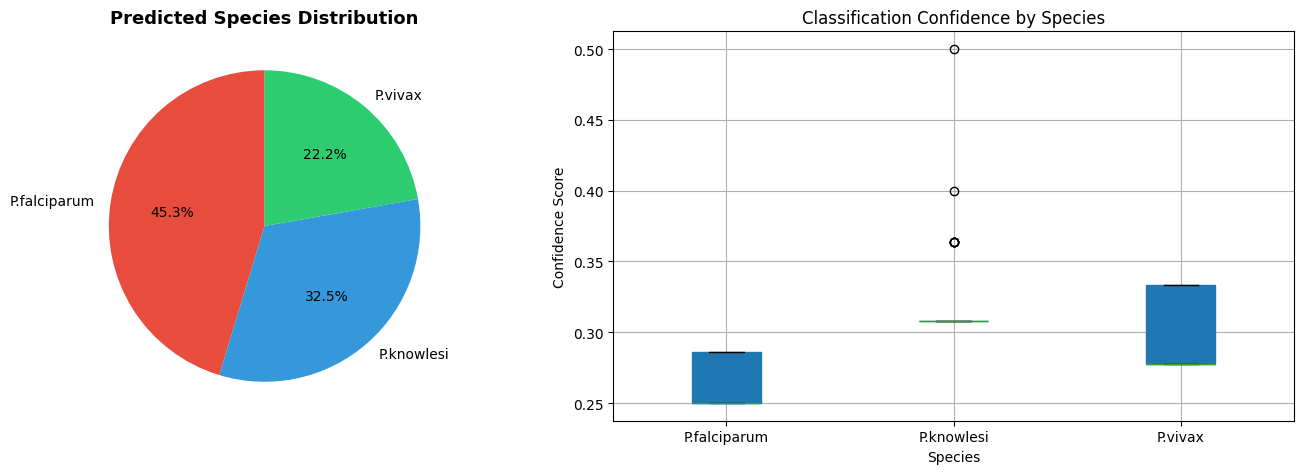

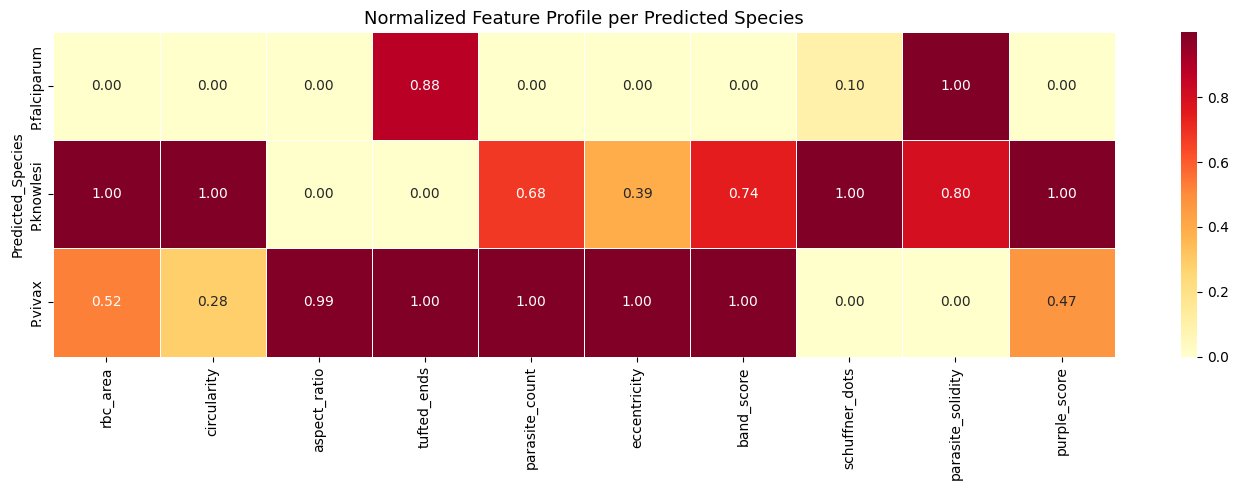

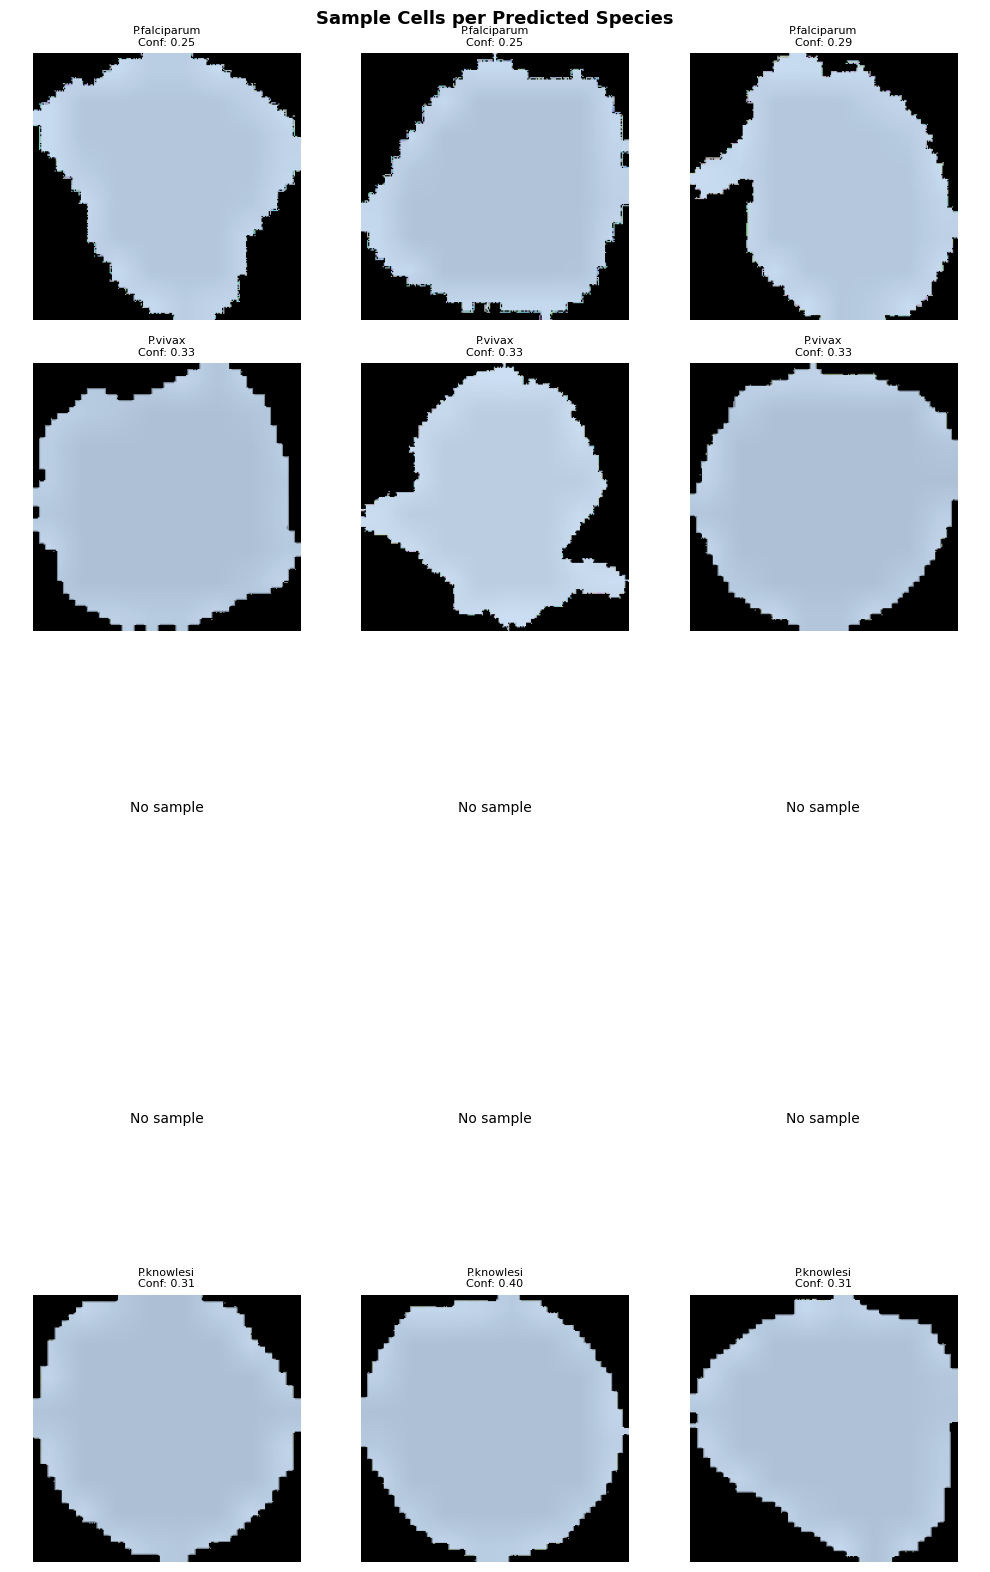

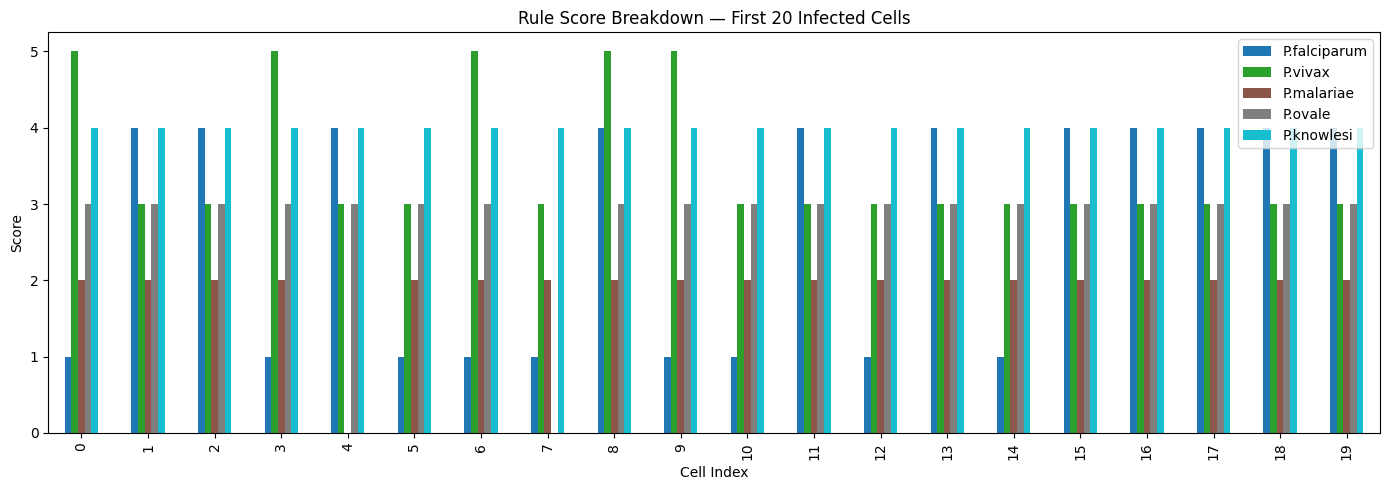


✅ All species classification plots saved!


In [ ]:
# STEP 1 — ENHANCED FEATURE EXTRACTOR
# Each feature maps directly to a species characteristic
# ================================================================

from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops

def extract_species_features(image_tensor):
    """
    Extract features that directly correspond to species differences
    seen in the morphology table.
    """
    img_np = ((image_tensor.numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    gray   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    hsv    = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    features = {}

    # -------------------------------------------------------
    # FEATURE GROUP 1: RBC SIZE & SHAPE
    # P.vivax → enlarged RBC
    # P.ovale → slightly enlarged + oval
    # Others  → normal size
    # -------------------------------------------------------
    _, cell_mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    contours, _ = cv2.findContours(
        cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    rbc_area        = 0
    circularity     = 0
    aspect_ratio    = 1.0
    solidity        = 1.0
    convexity       = 1.0
    tufted_ends     = 0   # P.ovale specific

    if contours:
        cnt  = max(contours, key=cv2.contourArea)
        rbc_area = cv2.contourArea(cnt)
        perim    = cv2.arcLength(cnt, True)

        if perim > 0:
            circularity = 4 * np.pi * rbc_area / (perim ** 2)

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / (h + 1e-6)   # >1.2 suggests oval (P.ovale)

        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity  = rbc_area / (hull_area + 1e-6)

        # Convexity defects — tufted ends of P.ovale show as defects
        hull_idx = cv2.convexHull(cnt, returnPoints=False)
        if hull_idx is not None and len(hull_idx) > 3 and len(cnt) > 3:
            defects = cv2.convexityDefects(cnt, hull_idx)
            if defects is not None:
                # Count significant defects (tufted ends)
                tufted_ends = sum(
                    1 for d in defects if d[0][3] / 256.0 > 5
                )

    features["rbc_area"]     = rbc_area
    features["circularity"]  = circularity
    features["aspect_ratio"] = aspect_ratio   # P.ovale > 1.2
    features["solidity"]     = solidity
    features["tufted_ends"]  = tufted_ends    # P.ovale indicator

    # -------------------------------------------------------
    # FEATURE GROUP 2: PARASITE SHAPE INSIDE CELL
    # P.malariae  → band shape (high eccentricity, low extent)
    # P.vivax     → amoeboid (irregular, low solidity)
    # P.falciparum→ small ring (low area, high euler holes)
    # -------------------------------------------------------
    _, para_mask = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)
    labeled_img  = label(para_mask)
    regions      = [r for r in regionprops(labeled_img) if r.area > 20]

    parasite_count     = len(regions)
    parasite_area      = 0
    eccentricity       = 0   # P.malariae band → high eccentricity (~0.9)
    extent             = 0   # schizonts fill bounding box more
    euler_number       = 0   # ring forms have holes → negative euler
    parasite_solidity  = 1.0 # P.vivax amoeboid → low solidity
    band_score         = 0   # P.malariae specific

    if regions:
        largest           = max(regions, key=lambda r: r.area)
        parasite_area     = largest.area
        eccentricity      = largest.eccentricity
        extent            = largest.extent
        euler_number      = largest.euler_number
        parasite_solidity = largest.solidity

        # Band score: P.malariae trophozoite spans the cell like a band
        # High eccentricity + spans width of cell = band
        bbox_width  = largest.bbox[3] - largest.bbox[1]
        bbox_height = largest.bbox[2] - largest.bbox[0]
        band_score  = bbox_width / (bbox_height + 1e-6)  # >2.0 = band shape

    features["parasite_count"]    = parasite_count     # P.knowlesi → high count
    features["parasite_area"]     = parasite_area
    features["eccentricity"]      = eccentricity       # P.malariae → ~0.9
    features["extent"]            = extent
    features["euler_number"]      = euler_number       # ring → negative
    features["parasite_solidity"] = parasite_solidity  # P.vivax → low
    features["band_score"]        = band_score         # P.malariae → >2.0
    features["parasite_area_ratio"] = parasite_area / (224 * 224)

    # -------------------------------------------------------
    # FEATURE GROUP 3: STAIN COLOR
    # P.falciparum → darker purple stain
    # P.vivax      → lighter, more pink
    # -------------------------------------------------------
    features["mean_hue"]        = hsv[:, :, 0].mean()
    features["mean_saturation"] = hsv[:, :, 1].mean()
    features["mean_value"]      = hsv[:, :, 2].mean()
    features["red_blue_ratio"]  = (
        img_np[:, :, 0].mean() / (img_np[:, :, 2].mean() + 1e-6)
    )
    # Purple intensity (P.falciparum stains more purple)
    features["purple_score"] = img_np[:, :, 2].mean() - img_np[:, :, 0].mean()

    # -------------------------------------------------------
    # FEATURE GROUP 4: SCHÜFFNER'S DOTS
    # Present in P.vivax and P.ovale — appear as bright speckles
    # -------------------------------------------------------
    _, dots_mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    dots_labeled  = label(dots_mask)
    dot_regions   = [r for r in regionprops(dots_labeled)
                     if 2 < r.area < 30]  # small bright spots only
    features["schuffner_dots"] = len(dot_regions)  # P.vivax/P.ovale → high

    # -------------------------------------------------------
    # FEATURE GROUP 5: TEXTURE (GLCM)
    # Different chromatin patterns per species
    # -------------------------------------------------------
    glcm = graycomatrix(
        gray, distances=[1, 3], angles=[0, np.pi/4],
        symmetric=True, normed=True
    )
    features["glcm_contrast"]     = graycoprops(glcm, "contrast").mean()
    features["glcm_energy"]       = graycoprops(glcm, "energy").mean()
    features["glcm_homogeneity"]  = graycoprops(glcm, "homogeneity").mean()
    features["glcm_correlation"]  = graycoprops(glcm, "correlation").mean()

    return features


# ================================================================
# STEP 2 — RULE-BASED SPECIES CLASSIFIER
# Rules derived directly from the morphology table
# ================================================================

def classify_species(f, thresholds=None):
    """
    Classify malaria species using morphological rules from the table.

    Rules:
    P.vivax     → enlarged RBC + Schüffner's dots + amoeboid parasite
    P.ovale     → slightly enlarged + oval shape + tufted ends + dots
    P.malariae  → normal RBC + band-shaped parasite
    P.knowlesi  → normal RBC + HIGH parasite count (multiple invasion)
    P.falciparum→ normal RBC + small ring forms (default / least features)
    """
    if thresholds is None:
        thresholds = {
            "large_rbc"      : 8000,   # pixel area — tune based on your images
            "medium_rbc"     : 5000,
            "oval_shape"     : 1.15,   # aspect ratio threshold
            "band_shape"     : 1.8,    # band_score threshold
            "high_parasites" : 3,      # multiple invasion count
            "dots_present"   : 5,      # Schüffner's dots count
            "ring_euler"     : -1,     # negative = hole = ring form
        }

    scores = {
        "P.falciparum" : 0,
        "P.vivax"      : 0,
        "P.malariae"   : 0,
        "P.ovale"      : 0,
        "P.knowlesi"   : 0,
    }

    # --- P.vivax indicators ---
    if f["rbc_area"] > thresholds["large_rbc"]:
        scores["P.vivax"] += 3        # enlarged RBC is strongest P.vivax sign
    if f["schuffner_dots"] > thresholds["dots_present"]:
        scores["P.vivax"] += 2        # Schüffner's dots
        scores["P.ovale"] += 1        # also present in P.ovale
    if f["parasite_solidity"] < 0.6:
        scores["P.vivax"] += 2        # amoeboid = irregular = low solidity

    # --- P.ovale indicators ---
    if f["aspect_ratio"] > thresholds["oval_shape"]:
        scores["P.ovale"] += 3        # oval-shaped RBC
    if f["tufted_ends"] > 2:
        scores["P.ovale"] += 3        # tufted ends are P.ovale specific
    if (f["rbc_area"] > thresholds["medium_rbc"] and
            f["rbc_area"] < thresholds["large_rbc"]):
        scores["P.ovale"] += 1        # slightly enlarged (not as big as vivax)

    # --- P.malariae indicators ---
    if f["band_score"] > thresholds["band_shape"]:
        scores["P.malariae"] += 4     # band form is highly specific
    if f["eccentricity"] > 0.85:
        scores["P.malariae"] += 2     # elongated parasite
    if f["rbc_area"] < thresholds["medium_rbc"]:
        scores["P.malariae"] += 1     # normal/small RBC

    # --- P.knowlesi indicators ---
    if f["parasite_count"] > thresholds["high_parasites"]:
        scores["P.knowlesi"] += 4     # multiple invasion = very specific
    if f["band_score"] > thresholds["band_shape"]:
        scores["P.knowlesi"] += 1     # can also show band form

    # --- P.falciparum indicators ---
    if f["euler_number"] <= thresholds["ring_euler"]:
        scores["P.falciparum"] += 3   # ring form with hole
    if f["rbc_area"] < thresholds["medium_rbc"]:
        scores["P.falciparum"] += 1   # RBC not enlarged
    if f["purple_score"] > 10:
        scores["P.falciparum"] += 1   # darker purple stain

    # Return species with highest score
    predicted = max(scores, key=scores.get)

    # Confidence = winning score / total score
    total = sum(scores.values())
    confidence = scores[predicted] / (total + 1e-6)

    return predicted, confidence, scores


# ================================================================
# STEP 3 — RUN ON ALL INFECTED IMAGES
# ================================================================

print("\n🔬 Extracting features and classifying species...")

all_features    = []
all_predictions = []
all_confidences = []
all_scores      = []
infected_imgs   = []

THRESHOLD = 0.50  # fixed from label bug correction

for x_batch, _ in test_ds:
    preds = model.predict(x_batch, verbose=0).ravel()
    mask  = preds >= THRESHOLD  # use optimal threshold

    infected_batch = x_batch.numpy()[mask]
    for img in infected_batch:
        img_tensor = tf.constant(img)
        feats      = extract_species_features(img_tensor)
        species, conf, score_dict = classify_species(feats)

        all_features.append(feats)
        all_predictions.append(species)
        all_confidences.append(conf)
        all_scores.append(score_dict)
        infected_imgs.append(img)


print(f"✅ Classified {len(all_predictions)} infected cells")


# ================================================================
# STEP 4 — RESULTS SUMMARY
# ================================================================

results_df = pd.DataFrame(all_features)
results_df["Predicted_Species"] = all_predictions
results_df["Confidence"]        = all_confidences

# Species distribution
print("\n📊 Species Distribution:")
print(results_df["Predicted_Species"].value_counts())

# Average confidence per species
print("\n🎯 Average Confidence per Species:")
print(results_df.groupby("Predicted_Species")["Confidence"].mean().round(3))


# ================================================================
# STEP 5 — VISUALIZATIONS
# ================================================================

# --- Plot 1: Species distribution pie chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

species_counts = results_df["Predicted_Species"].value_counts()
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

axes[0].pie(
    species_counts.values,
    labels=species_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
axes[0].set_title("Predicted Species Distribution", fontsize=13, fontweight="bold")

# --- Plot 2: Confidence by species ---
results_df.boxplot(
    column="Confidence",
    by="Predicted_Species",
    ax=axes[1],
    patch_artist=True
)
axes[1].set_title("Classification Confidence by Species")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Confidence Score")
plt.suptitle("")
plt.tight_layout()
plt.savefig("/content/species_distribution.png", dpi=150)
plt.show()


# --- Plot 3: Feature heatmap per species ---
feature_cols = [
    "rbc_area", "circularity", "aspect_ratio", "tufted_ends",
    "parasite_count", "eccentricity", "band_score",
    "schuffner_dots", "parasite_solidity", "purple_score"
]

species_profile = results_df.groupby("Predicted_Species")[feature_cols].mean()

# Normalize for heatmap
norm = (species_profile - species_profile.min()) / (
    species_profile.max() - species_profile.min() + 1e-6
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Normalized Feature Profile per Predicted Species", fontsize=13)
plt.tight_layout()
plt.savefig("/content/species_feature_heatmap.png", dpi=150)
plt.show()


# --- Plot 4: Sample images per species ---
fig, axes = plt.subplots(5, 3, figsize=(10, 16))
species_list = ["P.falciparum", "P.vivax", "P.malariae", "P.ovale", "P.knowlesi"]

for row, sp in enumerate(species_list):
    indices = [i for i, p in enumerate(all_predictions) if p == sp][:3]
    for col in range(3):
        ax = axes[row][col]
        if col < len(indices):
            img = infected_imgs[indices[col]]
            img_show = ((img + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
            ax.imshow(img_show)
            ax.set_title(
                f"{sp}\nConf: {all_confidences[indices[col]]:.2f}",
                fontsize=8
            )
        else:
            ax.text(0.5, 0.5, "No sample", ha="center", va="center")
        ax.axis("off")

plt.suptitle("Sample Cells per Predicted Species", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/species_samples.png", dpi=150)
plt.show()


# --- Plot 5: Score breakdown for first 20 cells ---
scores_df = pd.DataFrame(all_scores[:20])
scores_df.plot(kind="bar", figsize=(14, 5), colormap="tab10")
plt.title("Rule Score Breakdown — First 20 Infected Cells")
plt.xlabel("Cell Index")
plt.ylabel("Score")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/content/species_scores.png", dpi=150)
plt.show()

print("\n✅ All species classification plots saved!")

In [ ]:
# 8. Save (use Keras native format)
model.save("/content/1_malaria.keras")
from google.colab import files
files.download("/content/1_malaria.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>